# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 19: HYBRID FUSION MODEL ON 10-GENRE PILOT
# ============================================================
# Purpose:
# This notebook combines the 10-genre structured model branch
# and the 10-genre audio CNN branch into a final hybrid
# genre classification model.
#
# The goal is to:
# 1. Load probability outputs from the 10-genre structured model
# 2. Load probability outputs from the 10-genre audio CNN
# 3. Fuse the two probability vectors
# 4. Evaluate hybrid performance on validation and test sets
# 5. Compare structured-only, CNN-only, and hybrid results
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ============================================================
# 2. LOAD 10-GENRE STRUCTURED OUTPUTS
# ============================================================

# Best model was SVM, but we load the saved "best" outputs directly
structured_test_probs = np.load("../data/processed/structured_test_probs_best_10genre.npy")

y_val_structured = np.load("../data/processed/y_val_structured_10genre.npy")
y_test_structured = np.load("../data/processed/y_test_structured_10genre.npy")

structured_classes = np.load(
    "../data/processed/structured_label_classes_10genre.npy",
    allow_pickle=True
)

with open("../data/processed/best_structured_model_name_10genre.txt", "r") as f:
    best_structured_model_name = f.read()

with open("../data/processed/best_structured_model_test_accuracy_10genre.txt", "r") as f:
    structured_test_accuracy = float(f.read())

# Load the matching validation probabilities for the best structured model
if best_structured_model_name == "Logistic Regression":
    val_probs_structured = np.load("../data/processed/val_probs_lr_10genre.npy")
elif best_structured_model_name == "Random Forest":
    val_probs_structured = np.load("../data/processed/val_probs_rf_10genre.npy")
else:
    val_probs_structured = np.load("../data/processed/val_probs_svm_10genre.npy")

print("Best 10-genre structured model:", best_structured_model_name)
print("10-genre structured test accuracy:", structured_test_accuracy)
print("10-genre structured classes:", structured_classes)

Best 10-genre structured model: SVM
10-genre structured test accuracy: 0.43177966101694915
10-genre structured classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock' 'Spoken']


In [3]:
# ============================================================
# 3A. LOAD 10-GENRE CNN OUTPUTS
# ============================================================

val_probs_cnn = np.load("../data/processed/val_probs_cnn_10genre.npy")
test_probs_cnn = np.load("../data/processed/test_probs_cnn_10genre.npy")

y_val_cnn = np.load("../data/processed/y_val_cnn_10genre.npy")
y_test_cnn = np.load("../data/processed/y_test_cnn_10genre.npy")

cnn_classes = np.load(
    "../data/processed/cnn_label_classes_10genre.npy",
    allow_pickle=True
)

with open("../data/processed/improved_cnn_test_accuracy_10genre.txt", "r") as f:
    improved_cnn_test_accuracy = float(f.read())

print("10-genre CNN test accuracy:", improved_cnn_test_accuracy)
print("10-genre CNN classes:", cnn_classes)

10-genre CNN test accuracy: 0.31409168243408203
10-genre CNN classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock' 'Spoken']


In [4]:
# ============================================================
# 3B. ALIGN STRUCTURED OUTPUTS TO THE CLEANED AUDIO SET
# ============================================================
# Notebook 17 removed unreadable audio files before training the CNN.
# Notebook 18 used the full original 10-genre metadata.
# So here we reproduce the same cleanup and use it to filter the
# structured validation/test outputs so both branches match exactly.

import librosa
import pandas as pd

pilot_df_full = pd.read_csv("../data/processed/audio_large_pilot_metadata_10genre.csv")

def can_load_audio(file_path, sr=22050, duration=3):
    try:
        audio, _ = librosa.load(file_path, sr=sr, duration=duration)
        return audio is not None and len(audio) > 0
    except:
        return False

pilot_df_full["can_load"] = pilot_df_full["audio_path"].apply(can_load_audio)

# Keep only rows that survived the audio cleanup in Notebook 17
pilot_df_clean = pilot_df_full[pilot_df_full["can_load"] == True].copy().reset_index(drop=True)

print("Original pilot shape:", pilot_df_full.shape)
print("Clean pilot shape:", pilot_df_clean.shape)

# Build masks on the FULL original dataframe
val_keep_mask = (
    (pilot_df_full["split"] == "validation") &
    (pilot_df_full["can_load"] == True)
).to_numpy()

test_keep_mask = (
    (pilot_df_full["split"] == "test") &
    (pilot_df_full["can_load"] == True)
).to_numpy()

# Filter structured outputs to the same cleaned rows
val_probs_structured = val_probs_structured[val_keep_mask[pilot_df_full["split"] == "validation"]]
y_val_structured = y_val_structured[val_keep_mask[pilot_df_full["split"] == "validation"]]

structured_test_probs = structured_test_probs[test_keep_mask[pilot_df_full["split"] == "test"]]
y_test_structured = y_test_structured[test_keep_mask[pilot_df_full["split"] == "test"]]

print("Aligned structured validation shape:", val_probs_structured.shape)
print("Aligned structured test shape:", structured_test_probs.shape)
print("Aligned y_val_structured shape:", y_val_structured.shape)
print("Aligned y_test_structured shape:", y_test_structured.shape)

C:\Users\jdevo\AppData\Local\Temp\ipykernel_11052\2499516349.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(file_path, sr=sr, duration=duration)
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Original pilot shape: (6329, 6)
Clean pilot shape: (6312, 6)
Aligned structured validation shape: (2167, 10)
Aligned structured test shape: (2356, 10)
Aligned y_val_structured shape: (2167,)
Aligned y_test_structured shape: (2356,)


In [5]:
# ============================================================
# 4. CHECK ALIGNMENT
# ============================================================

print("Validation labels match:", np.array_equal(y_val_structured, y_val_cnn))
print("Test labels match:", np.array_equal(y_test_structured, y_test_cnn))
print("Class labels match:", np.array_equal(structured_classes, cnn_classes))

Validation labels match: True
Test labels match: True
Class labels match: True


In [6]:
# ============================================================
# 5. DEFINE FUSION FUNCTION
# ============================================================

def fuse_probabilities(probs_structured, probs_cnn, w_structured=0.5, w_cnn=0.5):
    return (w_structured * probs_structured) + (w_cnn * probs_cnn)

In [7]:
# ============================================================
# 6. TRY DIFFERENT FUSION WEIGHTS ON VALIDATION SET
# ============================================================

fusion_results = []

weight_options = [
    (0.1, 0.9),
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1),
]

for w_structured, w_cnn in weight_options:
    fused_val_probs = fuse_probabilities(
        val_probs_structured,
        val_probs_cnn,
        w_structured=w_structured,
        w_cnn=w_cnn
    )

    fused_val_pred = np.argmax(fused_val_probs, axis=1)
    fused_val_acc = accuracy_score(y_val_structured, fused_val_pred)

    fusion_results.append({
        "Structured Weight": w_structured,
        "CNN Weight": w_cnn,
        "Validation Accuracy": fused_val_acc
    })

fusion_results_df = pd.DataFrame(fusion_results)

print("10-Genre Fusion Validation Results:")
display(fusion_results_df.sort_values("Validation Accuracy", ascending=False))

10-Genre Fusion Validation Results:


,Structured Weight,CNN Weight,Validation Accuracy
3,0.4,0.6,0.503000
4,0.5,0.5,0.494693
2,0.3,0.7,0.482234
5,0.6,0.4,0.480849
6,0.7,0.3,0.477157
7,0.8,0.2,0.468389
8,0.9,0.1,0.459622
1,0.2,0.8,0.437471
0,0.1,0.9,0.401938


In [8]:
# ============================================================
# 7. SELECT BEST FUSION WEIGHTS
# ============================================================

best_row = fusion_results_df.sort_values("Validation Accuracy", ascending=False).iloc[0]

best_w_structured = best_row["Structured Weight"]
best_w_cnn = best_row["CNN Weight"]
best_fusion_val_acc = best_row["Validation Accuracy"]

print("Best 10-genre fusion weights:")
print("Structured weight:", best_w_structured)
print("CNN weight:", best_w_cnn)
print("Best 10-genre fusion validation accuracy:", best_fusion_val_acc)

Best 10-genre fusion weights:
Structured weight: 0.4
CNN weight: 0.6
Best 10-genre fusion validation accuracy: 0.5029995385325334


In [9]:
# ============================================================
# 8. EVALUATE 10-GENRE HYBRID MODEL ON TEST SET
# ============================================================

hybrid_test_probs = fuse_probabilities(
    structured_test_probs,
    test_probs_cnn,
    w_structured=best_w_structured,
    w_cnn=best_w_cnn
)

hybrid_test_pred = np.argmax(hybrid_test_probs, axis=1)
hybrid_test_accuracy = accuracy_score(y_test_structured, hybrid_test_pred)

print("10-Genre Hybrid Test Accuracy:", hybrid_test_accuracy)

10-Genre Hybrid Test Accuracy: 0.47156196943972833


In [10]:
# ============================================================
# 9. 10-GENRE HYBRID CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_test_structured,
    hybrid_test_pred,
    target_names=structured_classes,
    zero_division=0
))

               precision    recall  f1-score   support

    Classical       0.58      0.44      0.50        25
   Electronic       0.31      0.52      0.39       207
 Experimental       0.73      0.39      0.51       858
         Folk       0.36      0.18      0.24       147
      Hip-Hop       0.70      0.63      0.66       103
 Instrumental       0.11      0.08      0.10       134
International       0.25      0.24      0.24        25
          Pop       0.02      0.02      0.02        85
         Rock       0.64      0.70      0.67       753
       Spoken       0.06      1.00      0.11        19

     accuracy                           0.47      2356
    macro avg       0.38      0.42      0.34      2356
 weighted avg       0.57      0.47      0.49      2356



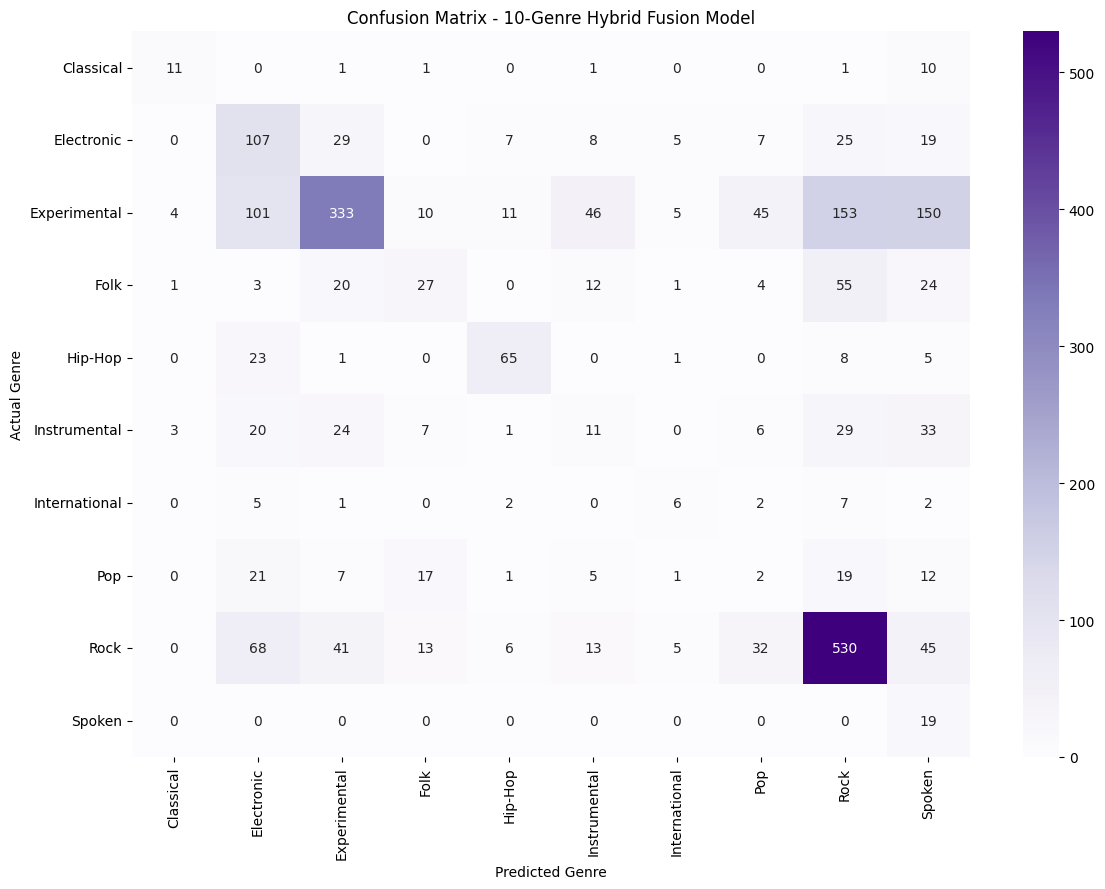

In [11]:
# ============================================================
# 10. 10-GENRE HYBRID CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_structured, hybrid_test_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=structured_classes,
    yticklabels=structured_classes
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - 10-Genre Hybrid Fusion Model")
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 11. FINAL 10-GENRE MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "10-Genre Best Structured Model",
        "10-Genre Audio CNN",
        "10-Genre Hybrid Fusion Model"
    ],
    "Test Accuracy": [
        structured_test_accuracy,
        improved_cnn_test_accuracy,
        hybrid_test_accuracy
    ]
})

print("10-Genre Final Model Comparison:")
display(final_comparison)

10-Genre Final Model Comparison:


,Model,Test Accuracy
0,10-Genre Best Structured Model,0.431780
1,10-Genre Audio CNN,0.314092
2,10-Genre Hybrid Fusion Model,0.471562


In [13]:
# ============================================================
# 12. SAVE 10-GENRE HYBRID RESULTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

with open("../data/processed/hybrid_test_accuracy_10genre.txt", "w") as f:
    f.write(str(hybrid_test_accuracy))

final_comparison.to_csv(
    "../data/processed/final_model_comparison_10genre.csv",
    index=False
)

print("Saved 10-genre hybrid results.")

Saved 10-genre hybrid results.


In [14]:
# ============================================================
# 13. INTERPRETATION NOTES
# ============================================================

print("1. This notebook combines the 10-genre structured and audio branches.")
print("2. Validation data is used to determine the best fusion weighting.")
print("3. Because the structured branch outperformed the audio branch, the best fusion weights may lean more heavily toward the structured model.")
print("4. The final result shows whether hybrid fusion still helps on the broader 10-genre task.")

1. This notebook combines the 10-genre structured and audio branches.
2. Validation data is used to determine the best fusion weighting.
3. Because the structured branch outperformed the audio branch, the best fusion weights may lean more heavily toward the structured model.
4. The final result shows whether hybrid fusion still helps on the broader 10-genre task.
